In [1]:
%%capture
# Install dependencies
!pip3 install torchrl
!pip3 install vmas
!pip3 install tqdm
!apt-get update -y
!apt-get install -y x11-utils xvfb python3-opengl libgl1-mesa-glx libglu1-mesa
!pip install pyvirtualdisplay

In [2]:
import copy
import tempfile
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
import pyvirtualdisplay
from PIL import Image
import numpy as np

from tensordict import TensorDictBase
from tensordict.nn import TensorDictModule, TensorDictSequential
from torch import multiprocessing
from torchrl.collectors import SyncDataCollector
from torchrl.data import LazyMemmapStorage, RandomSampler, ReplayBuffer
from torchrl.envs import (
    check_env_specs,
    RewardSum,
    TransformedEnv,
    VmasEnv,
)
from torchrl.modules import (
    AdditiveGaussianModule,
    MLP,
    ProbabilisticActor,
    TanhDelta,
)
from torchrl.objectives import DDPGLoss, SoftUpdate, ValueEstimators
from tqdm import tqdm

# --- Setup Virtual Display ---
try:
    display = pyvirtualdisplay.Display(visible=False, size=(1400, 900))
    display.start()
    print("Virtual display started.")
except Exception as e:
    print(f"Could not start virtual display: {e}")

Virtual display started.


In [3]:
seed = 0
is_fork = multiprocessing.get_start_method() == "fork"
device = torch.device(0) if torch.cuda.is_available() and not is_fork else torch.device("cpu")
torch.manual_seed(seed)
print(f"Using device: {device}")

# Vmas Environment
scenario_name = "navigation"
n_agents = 3
max_steps = 100  # Episode steps before done

# Sampling
frames_per_batch = 2000
n_iters = 500
total_frames = frames_per_batch * n_iters
num_vmas_envs = frames_per_batch // max_steps

# Replay Buffer
memory_size = 2_000_000

# Training
n_optimiser_steps = 10
train_batch_size = 512
lr = 3e-4
max_grad_norm = 1.0

# DDPG Algorithm
gamma = 0.99
polyak_tau = 0.005

Using device: cpu


In [4]:
# we use seprate groups for each agent(because we are using IDDPG)
group_map = {f"agent_{i}": [f"agent_{i}"] for i in range(n_agents)}

env = VmasEnv(
    scenario=scenario_name,
    num_envs=num_vmas_envs,
    continuous_actions=True,
    max_steps=max_steps,
    device=device,
    n_agents=n_agents,
    group_map=group_map,
)


env = TransformedEnv(
    env,
    RewardSum(
        in_keys=env.reward_keys,
        reset_keys=["_reset"] * len(env.group_map.keys()),
    ),
)



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [6]:
# Part 1: Create the Actor Networks (One per agent)
policy_modules = {}
for group, agents in env.group_map.items():
    # In IDDPG, a group contains just one agent
    agent_name = agents[0]
    actor_module = MLP(
        in_features=env.observation_spec[agent_name, "observation"].shape[-1],
        out_features=env.full_action_spec[agent_name, "action"].shape[-1],
        num_cells=[256, 256],
        activation_class=nn.ReLU,
    )
    # Wrap in TensorDictModule
    policy_module = TensorDictModule(
        module=actor_module,
        in_keys=[(agent_name, "observation")],
        out_keys=[(agent_name, "param")],
    )
    policy_modules[group] = TensorDictSequential(policy_module)


# Create Probabilistic Policies
policies = {}
for group, agents in env.group_map.items():
    agent_name = agents[0]
    policy = ProbabilisticActor(
        module=policy_modules[group],
        spec=env.full_action_spec[agent_name, "action"],
        in_keys=[(agent_name, "param")],
        out_keys=[(agent_name, "action")],
        distribution_class=TanhDelta,
        distribution_kwargs={
            "low": env.full_action_spec_unbatched[agent_name, "action"].space.low,
            "high": env.full_action_spec_unbatched[agent_name, "action"].space.high,
        },
        return_log_prob=False,
    )
    policies[group] = policy

# Create Target Policies for DDPG
target_policies = copy.deepcopy(policies)

# Create Exploration Policies
exploration_policies = {}
for group in env.group_map.keys():
    exploration_policies[group] = TensorDictSequential(
        policies[group],
        AdditiveGaussianModule(
            spec=policies[group].spec,
            annealing_num_steps=total_frames // 3,
            action_key=(group, "action"),
            sigma_init=0.5,
            sigma_end=0.05,
        ),
    )

In [7]:
# Part 2: Create the Independent Critic Networks (One per agent)
critics = {}
for group, agents in env.group_map.items():
    # In IDDPG, the critic only sees its own agent's observation and action
    agent_name = agents[0]
    critic_in_features = (
        env.observation_spec[agent_name, "observation"].shape[-1]
        + env.full_action_spec[agent_name, "action"].shape[-1]
    )

    # 1. Create an MLP critic for this specific agent
    critic_mlp = MLP(
        in_features=critic_in_features,
        out_features=1,
        num_cells=[256, 256],
        activation_class=nn.ReLU,
    )

    # 2. Create a module to concatenate the agent's obs and action
    cat_module = TensorDictModule(
        lambda obs, act: torch.cat([obs, act], dim=-1),
        in_keys=[(agent_name, "observation"), (agent_name, "action")],
        out_keys=[(group, "obs_action_cat")],
    )

    # 3. Create the final TDModule for the critic
    td_critic_module = TensorDictModule(
        module=critic_mlp,
        in_keys=[(group, "obs_action_cat")],
        out_keys=[(group, "state_action_value")],
    )

    # 4. Combine them into a sequence
    critics[group] = TensorDictSequential(cat_module, td_critic_module)


print("Actor and Critic models created for IDDPG.")


Actor and Critic models created for IDDPG.


In [11]:
# Part 3: Replay Buffer, Losses, and Optimizers
shared_replay_buffer = ReplayBuffer(
    storage=LazyMemmapStorage(memory_size, scratch_dir=tempfile.TemporaryDirectory().name),
    sampler=RandomSampler(),
    batch_size=train_batch_size,
)
if device.type != "cpu":
    shared_replay_buffer.append_transform(lambda x: x.to(device))

losses = {}
for group in env.group_map.keys():
    loss_module = DDPGLoss(
        actor_network=policies[group],
        value_network=critics[group],
        delay_value=True,
        delay_actor=True,
        loss_function="l2",
    )
    loss_module.set_keys(
        state_action_value=(group, "state_action_value"),
        reward=(group, "reward"),
        done=(group, "done"),
        terminated=(group, "terminated"),
    )
    loss_module.make_value_estimator(ValueEstimators.TD0, gamma=gamma)
    losses[group] = loss_module

target_updaters = {group: SoftUpdate(loss, tau=polyak_tau) for group, loss in losses.items()}
optimisers = {
    group: {
        "loss_actor": torch.optim.Adam(loss.actor_network_params.flatten_keys().values(), lr=lr),
        "loss_value": torch.optim.Adam(loss.value_network_params.flatten_keys().values(), lr=lr),
    }
    for group, loss in losses.items()
}
print("Losses, optimizers, and replay buffer are ready.")

Losses, optimizers, and replay buffer are ready.


In [16]:
# Data Collection and Training
collector = SyncDataCollector(
    env,
    TensorDictSequential(*exploration_policies.values()),
    device=device,
    frames_per_batch=frames_per_batch,
    total_frames=total_frames,
)

# This helper function is needed to handle 'done' and 'terminated' keys
def process_batch(batch: TensorDictBase) -> TensorDictBase:
    for group in env.group_map.keys():
        keys = list(batch.keys(True, True))
        group_shape = batch.get_item_shape(group)
        nested_done_key = ("next", group, "done")
        nested_terminated_key = ("next", group, "terminated")
        if nested_done_key not in keys:
            batch.set(
                nested_done_key,
                batch.get(("next", "done")).unsqueeze(-1).expand((*group_shape, 1)),
            )
        if nested_terminated_key not in keys:
            batch.set(
                nested_terminated_key,
                batch.get(("next", "terminated"))
                .unsqueeze(-1)
                .expand((*group_shape, 1)),
            )
    return batch

# Training Loop
episode_reward_mean_map = {group: [] for group in env.group_map.keys()}
pbar = tqdm(total=n_iters, desc="Training Progress")

for iteration, batch in enumerate(collector):
    current_frames = batch.numel()
    batch = process_batch(batch)
    shared_replay_buffer.extend(batch.reshape(-1))

    for group in env.group_map.keys(): # This loop will train each agent independently
        for _ in range(n_optimiser_steps):
            subdata = shared_replay_buffer.sample()

            with torch.no_grad():
                next_td = subdata.get("next")
                # Get target actions for the next state from ALL agents' target policies
                for other_group in env.group_map.keys():
                    target_policy = target_policies[other_group]
                    # Select the action from the tensordict returned by the policy
                    action_td = target_policy(next_td).select((other_group, "action"))
                    next_td.update(action_td)


            loss_vals = losses[group](subdata)
            for loss_name in ["loss_actor", "loss_value"]:
                loss = loss_vals[loss_name]
                optimiser = optimisers[group][loss_name]
                loss.backward()
                params = optimiser.param_groups[0]["params"]
                torch.nn.utils.clip_grad_norm_(params, max_grad_norm)
                optimiser.step()
                optimiser.zero_grad()
            target_updaters[group].step()

    # Update exploration noise
    for group in env.group_map.keys():
        exploration_policies[group][-1].step(current_frames)

    # Log rewards
    for group in env.group_map.keys():
        done_mask = batch.get(("next", group, "done"))
        if done_mask.any():
            episode_reward_mean = batch.get(("next", group, "episode_reward"))[done_mask].mean().item()
            episode_reward_mean_map[group].append(episode_reward_mean)

    if iteration % 10 == 0 and len(episode_reward_mean_map[f"agent_0"]) > 0:
        reward_strings = [f"{group}: {episode_reward_mean_map[group][-1]:.2f}" for group in env.group_map.keys()]
        description = f"Iter [{iteration+1}/{n_iters}] | Rewards: " + " | ".join(reward_strings)
        pbar.set_description(description)
    pbar.update(1)

pbar.close()
collector.shutdown()
print("\nTraining finished.")

Training Progress:   0%|          | 0/500 [00:18<?, ?it/s]
Iter [491/500] | Rewards: agent_0: 2.87 | agent_1: 2.91 | agent_2: 2.87: 100%|██████████| 500/500 [24:34<00:00,  2.95s/it]


Training finished.


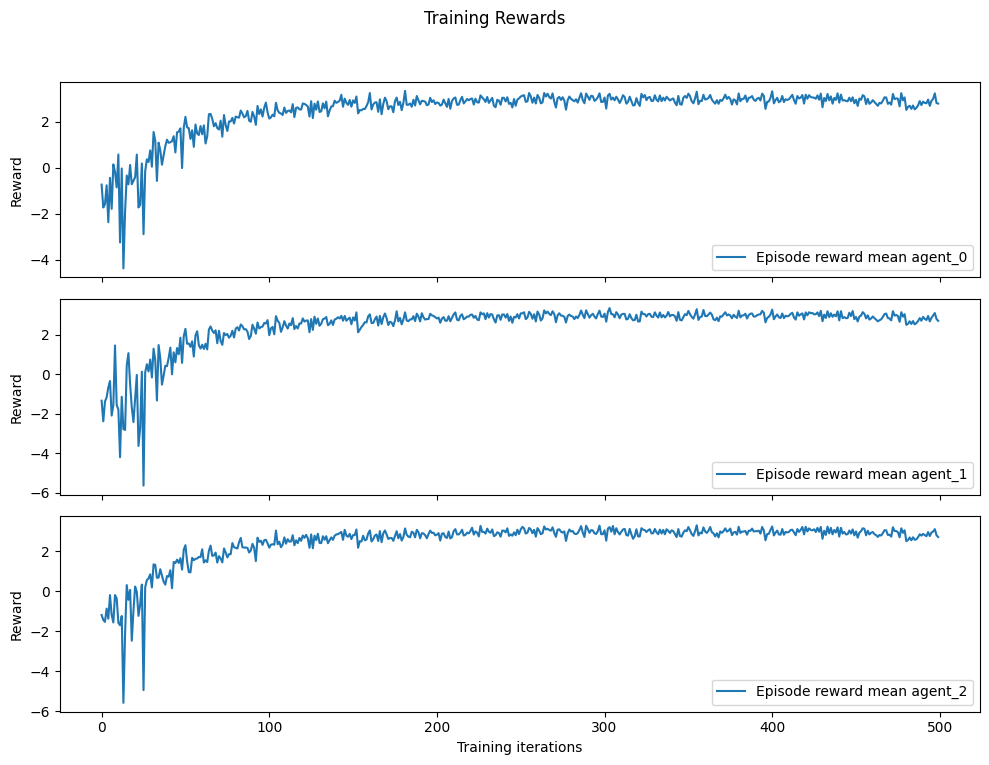

In [17]:
fig, axs = plt.subplots(n_agents, 1, figsize=(10, 8), sharex=True)
if n_agents == 1:
    axs = [axs]
for i, group in enumerate(env.group_map.keys()):
    axs[i].plot(episode_reward_mean_map[group], label=f"Episode reward mean {group}")
    axs[i].set_ylabel("Reward")
    axs[i].legend()
axs[-1].set_xlabel("Training iterations")
fig.suptitle("Training Rewards")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

✅ Saved animation as navigation_IDDPG.gif


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


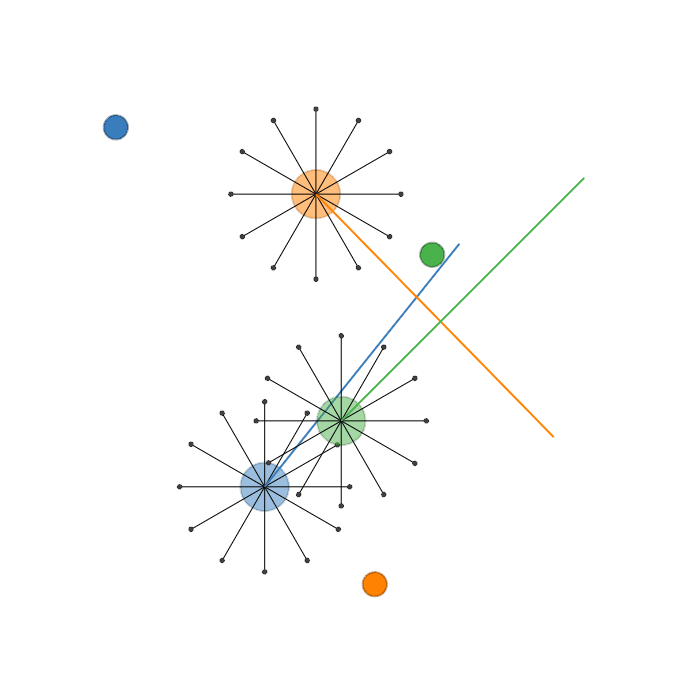

In [20]:
render_env = VmasEnv(
    scenario=scenario_name,
    num_envs=1,
    continuous_actions=True,
    max_steps=max_steps,
    device=device,
    n_agents=n_agents,
    group_map=group_map,
)

td = render_env.reset()
frames = []

with torch.no_grad():
    for _ in range(max_steps):
        for group in render_env.group_map.keys():
            td = policies[group](td)
        td_next = render_env.step(td)
        td = td_next.get("next").clone()

        frame = render_env.render(mode="rgb_array")
        frames.append(Image.fromarray(frame))

gif_path = f"{scenario_name}_IDDPG.gif"
frames[0].save(
    gif_path,
    save_all=True,
    append_images=frames[1:],
    duration=100,
    loop=0,
)
print(f"✅ Saved animation as {gif_path}")
from IPython.display import Image as IPImage
IPImage(filename=gif_path)